## 4. Naive Bayes 

### 4.1 Packages Importeren

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, classification_report, accuracy_score
)
from scipy import stats

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)

### 4.2 Dataset inladen 

In [ ]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# training set
X_train = train['Omschrijving']
y_train = train['Product']

# test set
X_test = test['Omschrijving']
y_test = test['Product']

### 4.3 Pipeline en Hyperparameter Tuning

#### 4.3.1 TF-IDF en Naive Bayes Pipeline

In [3]:
tfidf = TfidfVectorizer(
        preprocessor=spacy_preprocessor,
        tokenizer=spacy_tokenizer,
        analyzer='word',
        ngram_range=(1,1),
        token_pattern=None,
        binary=True,
        min_df=2,
        max_df=0.95
    )

nb_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', MultinomialNB())
])

#### 4.3.2 RandomizedSearchCV

In [ ]:
random_params = {
    # Modelparameters
    "model__alpha": stats.loguniform(1e-4, 50),  # maakt het model minder gevoelig voor zeldzame woorden
    "model__fit_prior": [True, False], # gebruikt de verdeling van klassen wel of niet

    # TF-IDF Parameters 
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__min_df": [1, 2, 3, 5, 10],
    "tfidf__max_df": [0.5, 0.65, 0.75, 0.85, 1.0],
    "tfidf__binary": [True, False],
    "tfidf__use_idf": [True, False],   
    "tfidf__norm": ["l1", "l2"],
}

random_search = RandomizedSearchCV(
    nb_pipeline,
    param_distributions=random_params,
    n_iter=80,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best = random_search.best_params_

print("\nBeste parameters Random Search: ")
print(best)

Fitting 3 folds for each of 80 candidates, totalling 240 fits

Beste parameters Random Search: 
{'model__alpha': np.float64(0.14900254733120494), 'model__fit_prior': True, 'tfidf__binary': False, 'tfidf__max_df': 0.65, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__use_idf': False}


#### 4.3.3 GridSearchCV

In [ ]:
# GridSearch om de beste instellingen uit Random Search verder af te stellen 
grid_params_nb = {
    "model__alpha": [
        best["model__alpha"] * 0.5,
        best["model__alpha"],
        best["model__alpha"] * 2
    ],
    "model__fit_prior": [best["model__fit_prior"]],

    "tfidf__min_df": [
        max(1, best["tfidf__min_df"] - 1),
        best["tfidf__min_df"],
        best["tfidf__min_df"] + 1
    ],
    "tfidf__max_df": [
        max(0.1, best["tfidf__max_df"] - 0.1),
        best["tfidf__max_df"],
        min(1.0, best["tfidf__max_df"] + 0.1)
    ],
    "tfidf__ngram_range": [best["tfidf__ngram_range"]],
    "tfidf__binary": [best["tfidf__binary"]],
    "tfidf__use_idf": [best["tfidf__use_idf"]],
    "tfidf__norm": [best["tfidf__norm"]],
}

In [6]:
grid = GridSearchCV(
    nb_pipeline,
    param_grid=grid_params_nb,
    scoring="precision_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)
nb_pipeline_best = grid.best_estimator_

print("\nBeste Parameters GridSearch: ")
print(grid.best_params_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Beste Parameters GridSearch: 
{'model__alpha': np.float64(0.07450127366560247), 'model__fit_prior': True, 'tfidf__binary': False, 'tfidf__max_df': 0.55, 'tfidf__min_df': 4, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__use_idf': False}


### 4.4 Evaluatie modelprestaties

#### 4.4.1 Voorspellingen

In [ ]:
y_pred_nb = nb_pipeline_best.predict(X_test)
y_proba_nb = nb_pipeline_best.predict_proba(X_test)

#### 4.4.2 Totale metrics

In [8]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')
auc_nb = roc_auc_score(y_test, y_proba_nb, multi_class='ovr')

print(f"AUC: {auc_nb:.3f}")
print(f'Accuracy Naive Bayes: {accuracy_nb:.3f}')
print(f"F1 Naive Bayes: {f1_nb:.3f}")

AUC: 0.964
Accuracy Naive Bayes: 0.826
F1 Naive Bayes: 0.819


#### 4.4.3 Classification Report

In [9]:
print('\nClassification report Naive Bayes:\n')
print(classification_report(y_test, y_pred_nb))


Classification report Naive Bayes:

                    precision    recall  f1-score   support

      Bankrekening       0.90      0.82      0.86       446
Consumentenkrediet       0.85      0.33      0.47       284
        Creditcard       0.79      0.80      0.80       564
         Hypotheek       0.85      0.95      0.90       994
           Incasso       0.83      0.84      0.84      1223
Kredietregistratie       0.78      0.84      0.81       934

          accuracy                           0.83      4445
         macro avg       0.83      0.76      0.78      4445
      weighted avg       0.83      0.83      0.82      4445



#### 4.4.4 Confusion Matrix Naive Bayes

[[ 365    2   39   18   12   10]
 [   6   93   29   67   52   37]
 [  20    2  453   13   39   37]
 [   9    0    8  944   10   23]
 [   6    5   21   45 1029  117]
 [   0    8   23   19   95  789]]


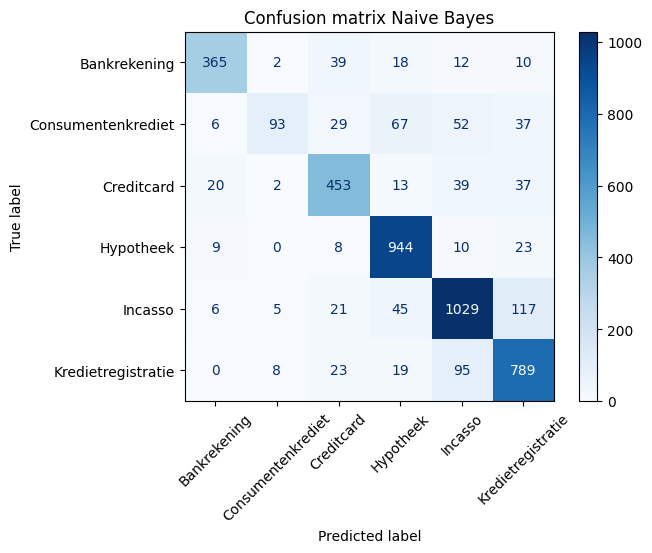

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix Naive Bayes')
plt.savefig("afbeeldingen/confusion_matrix_naive_bayes.png", dpi=300, bbox_inches='tight') 
plt.show()

### 4.4.5 Conclusie modelprestatie

Naive Bayes haalt een weighted precision van 0,83. Alleen Bankrekening haalt de minimale eis van 90% precision. Voor de andere productsectoren ligt de precision lager, tussen 0,78 en 0,85. Vooral Consumentenkrediet scoort zwak, wat ook duidelijk te zien is in de confusion matrix.

Net als bij Logistic Regression wordt de eis van 90% precision voor alle subklassen niet gehaald. Het model presteert daarom niet beter dan Logistic Regression.